# **UK E-Commerce Customer Analytics & Retention Analysis**

# Executive Summary

This project analyzes UK-based e-commerce transactions to understand customer purchasing behavior, revenue trends, product performance, and customer retention.

Key objectives:

- Identify revenue growth patterns
- Discover top-performing products
- Understand geographic sales distribution
- Segment customers using RFM Analysis
- Evaluate customer retention through Cohort Analysis

Business Impact:

The analysis helps management identify high-value customers, improve retention strategies, optimize product offerings, and maximize revenue opportunities.

## Business Objectives

The analysis aims to answer the following business questions:

1. What are the overall revenue and sales trends?
2. Which products contribute most to revenue?
3. Which countries generate the highest sales?
4. Who are the most valuable customers?
5. Which customer segments are at risk of churn?
6. How effectively does the business retain customers?
7. What strategies can improve revenue and customer retention?

## Dataset Overview

Dataset: UK Online Retail Dataset

Period Covered:
December 2010 - December 2011

Features:
- Invoice Number
- Product Description
- Quantity
- Unit Price
- Customer ID
- Country
- Invoice Date

Source:
UCI Machine Learning Repository

In [74]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/data.csv', encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [75]:
# Check Data Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


##Data Cleaning

In [76]:
df = df.dropna(subset=["CustomerID"])
df = df.drop_duplicates()
print(f"New Dataset after cleaning : {df.shape}")

New Dataset after cleaning : (401604, 8)


In [77]:
# 1. Adaptively convert the dates using the 'mixed' format parser
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed')

# 2. Double-check: Count if ANY dates accidentally became missing/NaN (NaT)
missing_dates = df['InvoiceDate'].isna().sum()
print(f"Number of unparsed/missing dates: {missing_dates}")

# 3. Look at the data types to confirm it is now a datetime64 object
print(df['InvoiceDate'].dtype)

Number of unparsed/missing dates: 0
datetime64[ns]


In [78]:

df_returns = df[df['Quantity'] < 0].copy()
df = df[df['Quantity'] > 0].copy()

#Creating total spend column
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']

print(f"Clean Purchases Dataset Shape: {df.shape}")
print(f"Isolated Returns Dataset Shape: {df_returns.shape}")
df.head()

Clean Purchases Dataset Shape: (392732, 9)
Isolated Returns Dataset Shape: (8872, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


##Calculating Metrics

In [79]:
#Total Revenue
total_revenue = df['TotalSpend'].sum()

#total Customers
total_customers = df['CustomerID'].nunique()

#Total Orders
total_orders=df['InvoiceNo'].nunique()

#Average Order Value
avg_order_value = total_revenue/total_orders

#Average Spend per Customer
avg_spend_per_customer = total_revenue/df['CustomerID'].nunique()

print(" ===   CORE E COMMERCE PERFORMANCE METRICS  === ")
print(f"Total Revenue: ${total_revenue:.2f}")
print(f"Total Orders: {total_orders}")
print(f"Total Unique Customers:    {total_customers:,}")
print(f"Average Order Value AOV : ${avg_order_value:.2f}")
print(f"Average Spend per Customer: ${avg_spend_per_customer:.2f}")


 ===   CORE E COMMERCE PERFORMANCE METRICS  === 
Total Revenue: $8887208.89
Total Orders: 18536
Total Unique Customers:    4,339
Average Order Value AOV : $479.46
Average Spend per Customer: $2048.22


In [80]:
df['InvoiceYearMonth'] =  df['InvoiceDate'].dt.to_period('M')

# Montly Revenue
monthly_revenue = df.groupby('InvoiceYearMonth')['TotalSpend'].sum().reset_index()
monthly_revenue['InvoiceYearMonth'] = monthly_revenue['InvoiceYearMonth'].astype(str)

print(monthly_revenue)

   InvoiceYearMonth   TotalSpend
0           2010-12   570422.730
1           2011-01   568101.310
2           2011-02   446084.920
3           2011-03   594081.760
4           2011-04   468374.331
5           2011-05   677355.150
6           2011-06   660046.050
7           2011-07   598962.901
8           2011-08   644051.040
9           2011-09   950690.202
10          2011-10  1035642.450
11          2011-11  1156205.610
12          2011-12   517190.440


In [81]:
df.tail()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend,InvoiceYearMonth
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011-12
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011-12
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011-12
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011-12
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,14.85,2011-12


#Data Visualization

###1. Monthly Revenue Trend

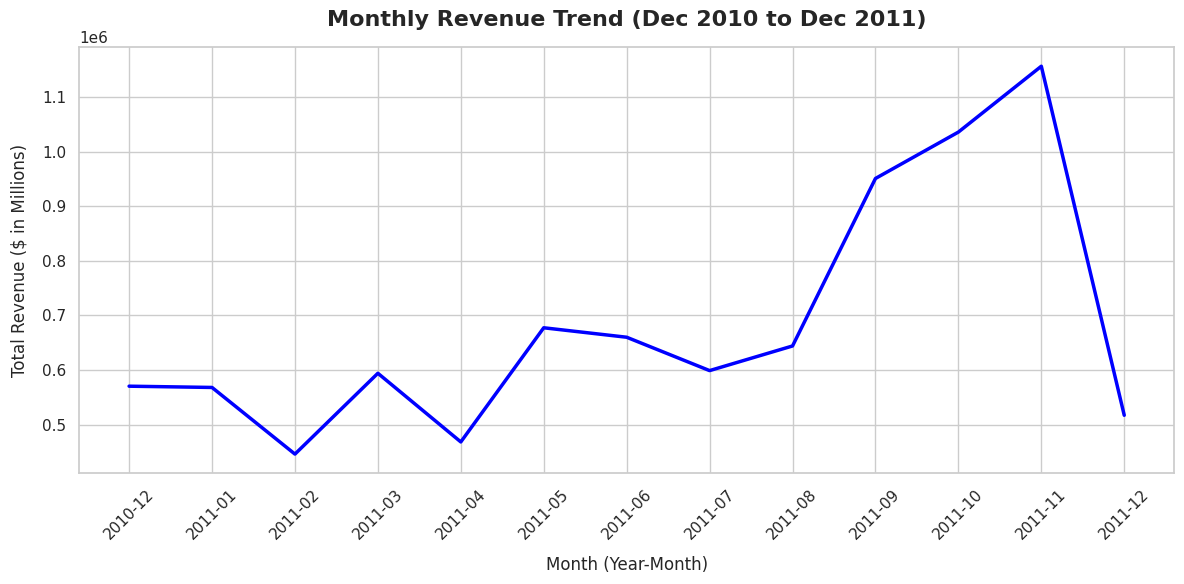

In [82]:
plt.figure(figsize=(12,6))
sns.set_theme(style="whitegrid")

#line Chart
sns.lineplot(
    data=monthly_revenue,
    x='InvoiceYearMonth',
    y='TotalSpend',
    markers = 0 ,
    linewidth=2.5,
    color='blue'

)

plt.title('Monthly Revenue Trend (Dec 2010 to Dec 2011)', fontsize = 16, fontweight = 'bold' , pad = 15 )
plt.xlabel('Month (Year-Month)', fontsize = 12 , labelpad = 10)
plt.ylabel('Total Revenue ($ in Millions)', fontsize= 12 , labelpad = 10)

plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

### Business Insight

The business maintained relatively stable revenue during the first half of 2011, followed by a strong growth phase from September to November. Revenue reached its annual peak in November at over $1.15 million before declining sharply in December.

### Why It Matters

The significant increase in Q4 suggests strong seasonal purchasing behavior, likely driven by holiday shopping and year-end demand.

### Recommended Action

- Increase inventory and marketing investment during September–November.
- Launch seasonal promotions earlier to capture demand.
- Investigate the December decline to determine whether it is due to incomplete monthly data or post-holiday demand reduction.

###2. Product Analysis

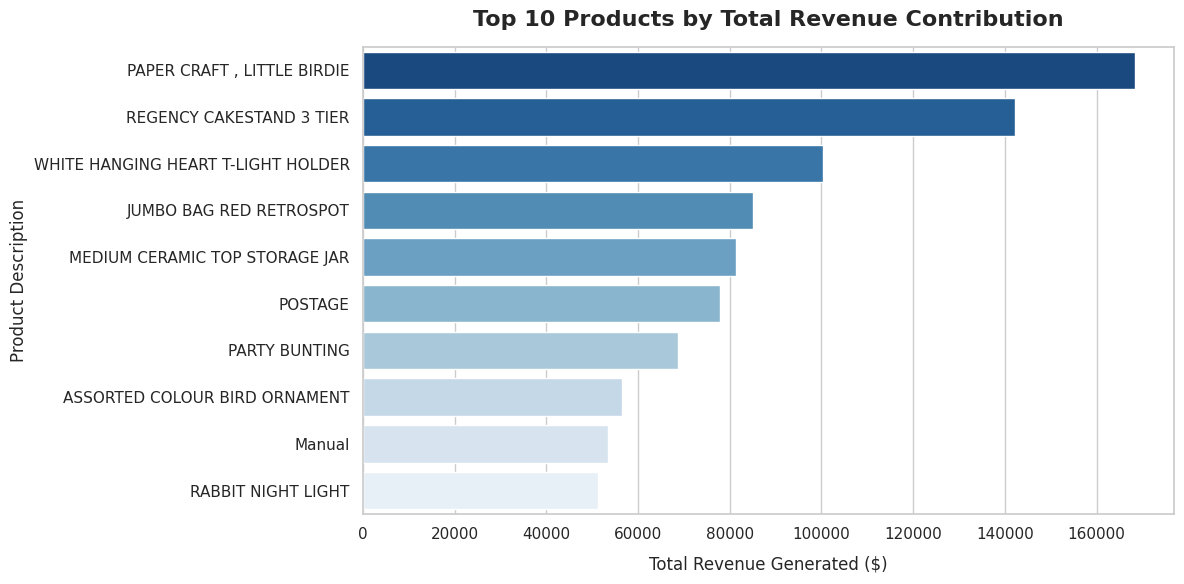

In [83]:
#Calculate top performing products
top_products = df.groupby('Description')['TotalSpend'].sum().sort_values(ascending=False).head(10).reset_index()


plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

#Bar Chart
sns.barplot(
    data=top_products,
    x='TotalSpend',
    y='Description',
    palette='Blues_r',
    hue='Description',
    legend=False
)


plt.title('Top 10 Products by Total Revenue Contribution', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Revenue Generated ($)', fontsize=12, labelpad=10)
plt.ylabel('Product Description', fontsize=12)


plt.tight_layout()
plt.show()

### Business Insight

A relatively small number of products contribute a disproportionately large share of total revenue. "PAPER CRAFT , LITTLE BIRDIE" and "REGENCY CAKESTAND 3 TIER" are the highest revenue-generating products in the catalog.

### Why It Matters

The business exhibits a concentration of revenue among a limited set of products, making these products critical drivers of financial performance.

### Recommended Action

- Maintain high stock availability for top-selling products.
- Bundle best-performing products with complementary items to increase Average Order Value (AOV).
- Analyze customer purchasing behavior around these products to identify cross-selling opportunities.

###Distribution of RFM Metrics (Histograms & KDE Density Curves)

In [84]:
# Set snapshot date to one day after the absolute last invoice in the data
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Group by CustomerID and calculate Recency, Frequency, and Monetary values
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Days since last order (Recency)
    'InvoiceNo': 'nunique',                                 # Total unique orders (Frequency)
    'TotalSpend': 'sum'                                     # Total cash spent (Monetary)
}).reset_index()

# Rename columns to make them professional and readable
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Print confirmation that the engine is loaded
print("RFM table successfully recreated and loaded into memory!")

RFM table successfully recreated and loaded into memory!


### 3. RFM Distribution Analysis

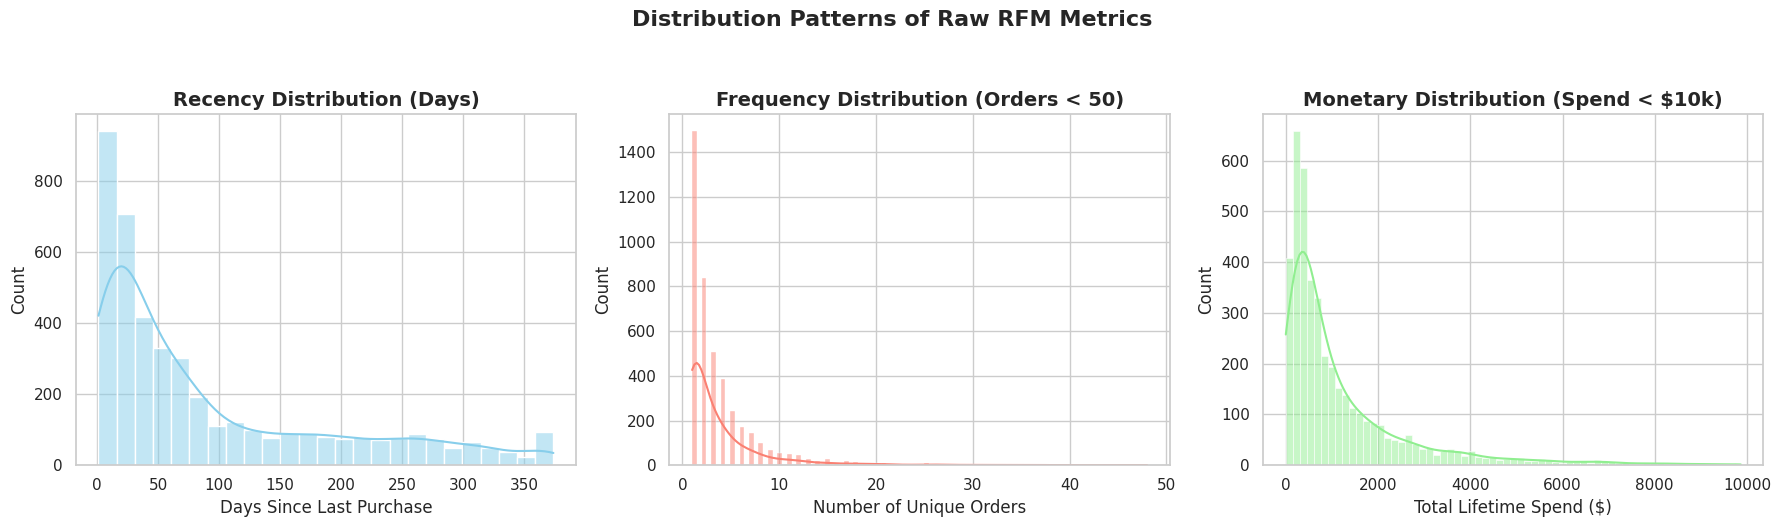

In [85]:

# fig handles the overall canvas; axes holds the 3 individual plots (axes[0], axes[1], axes[2])
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2. PLOT 1: Recency (Days since last purchase)

sns.histplot(rfm['Recency'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Recency Distribution (Days)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Days Since Last Purchase')

# 3. PLOT 2: Frequency (Total unique orders placed)
# Business rule: We filter to [Frequency < 50] so a few extreme buyers don't squish the chart
sns.histplot(rfm[rfm['Frequency'] < 50]['Frequency'], kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Frequency Distribution (Orders < 50)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Unique Orders')

# 4. PLOT 3: Monetary (Lifetime spend)
# Business rule: We filter to [Monetary < 10000] to keep the visual scale readable for standard users
sns.histplot(rfm[rfm['Monetary'] < 10000]['Monetary'], kde=True, color='lightgreen', ax=axes[2])
axes[2].set_title('Monetary Distribution (Spend < $10k)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Total Lifetime Spend ($)')

# 5. Add a master overarching title for the entire dashboard layout
# y=1.05 pushes the title slightly up so it doesn't collide with the sub-charts
plt.suptitle('Distribution Patterns of Raw RFM Metrics', fontsize=16, fontweight='bold', y=1.05)

# 6. Automatically adjust spacing and margins between the 3 charts so nothing overlaps
plt.tight_layout()

# 7. Render the final 3-part layout grid on screen
plt.show()

### Business Insight

All three RFM metrics display highly skewed distributions.

- Most customers purchased recently, while a smaller group has remained inactive for extended periods.
- The majority of customers place only a few orders.
- A small percentage of customers account for significantly higher spending than the average customer.

### Why It Matters

Customer value is unevenly distributed. A small number of highly engaged customers contribute a substantial portion of overall revenue.

### Recommended Action

- Develop retention strategies for high-value customers.
- Encourage repeat purchases among low-frequency buyers.
- Use personalized campaigns to increase customer lifetime value.

###4. Geographic Analysis

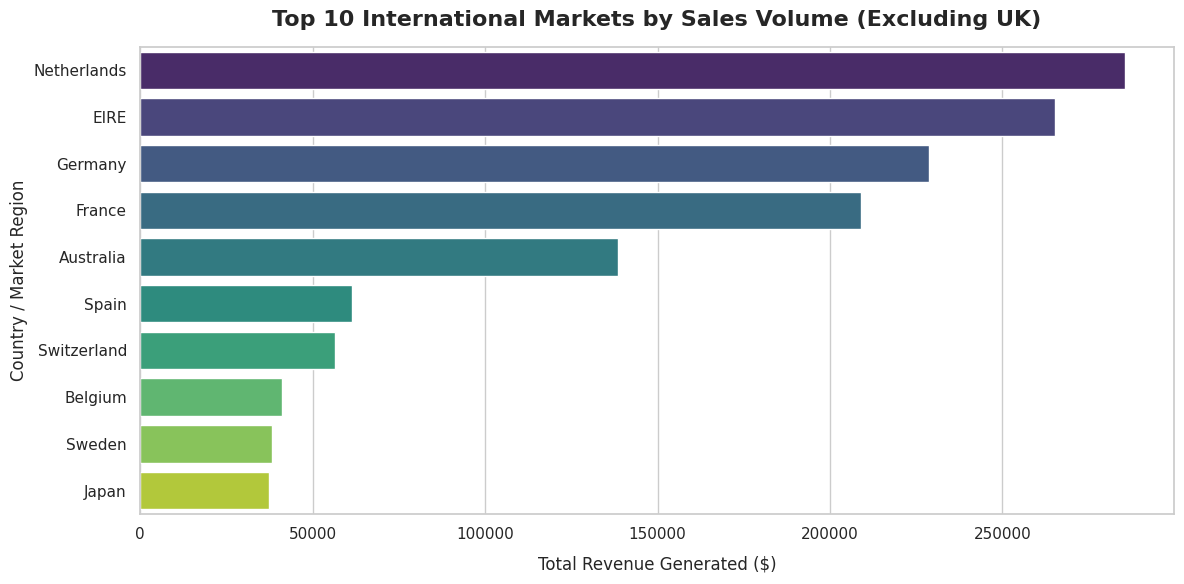

In [86]:
# 1. Group by Country, sum spend, and filter out the UK to focus purely on international expansion markets
intl_sales = df[df['Country'] != 'United Kingdom'].groupby('Country')['TotalSpend'].sum().sort_values(ascending=False).head(10).reset_index()

# 2. Create the horizontal canvas
plt.figure(figsize=(12, 6))

# 3. Plot using an elegant green-to-blue gradient palette
sns.barplot(
    data=intl_sales,
    x='TotalSpend',
    y='Country',
    palette='viridis',
    hue='Country',
    legend=False
)

# 4. Add formatting and clear context titles
plt.title('Top 10 International Markets by Sales Volume (Excluding UK)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Revenue Generated ($)', fontsize=12, labelpad=10)
plt.ylabel('Country / Market Region', fontsize=12)

# 5. Render
plt.tight_layout()
plt.show()

### Business Insight

The Netherlands, EIRE, Germany, and France generate the highest revenue among international markets, significantly outperforming other countries.

### Why It Matters

The company already has strong market penetration in several European regions, indicating opportunities for international expansion beyond the domestic UK market.

### Recommended Action

- Increase localized marketing efforts in top-performing countries.
- Introduce region-specific promotional campaigns.
- Evaluate logistics and shipping strategies to support growth in high-potential international markets.

In [87]:
# 1. Calculate the raw quintile rankings (1-5)
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

# 2. Combine individual scores into an RFM Cell string (e.g., '555')
rfm['RFM_Cell'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# 3. Define a map that groups numeric scores into clear business segments
def find_segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])

    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New & Recent Buyers'
    elif r <= 2 and f >= 4:
        return 'At Risk VIPs'
    elif r <= 2 and f <= 2:
        return 'Hibernating / Lost'
    else:
        return 'About to Sleep'

# 4. Apply the segment logic to every customer row
rfm['Segment'] = rfm.apply(find_segment, axis=1)

# 5. Print a summary count of our new segments
print(rfm['Segment'].value_counts())
print("\n=== SEGMENTATION SUCCESSFUL ===")
rfm.head()

Segment
Champions              1139
Hibernating / Lost     1065
Loyal Customers         821
About to Sleep          718
New & Recent Buyers     320
At Risk VIPs            276
Name: count, dtype: int64

=== SEGMENTATION SUCCESSFUL ===


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Cell,Segment
0,12346.0,326,1,77183.60,1,1,5,115,Hibernating / Lost
1,12347.0,2,7,4310.00,5,5,5,555,Champions
2,12348.0,75,4,1797.24,2,4,4,244,At Risk VIPs
3,12349.0,19,1,1757.55,4,1,4,414,New & Recent Buyers
4,12350.0,310,1,334.40,1,1,2,112,Hibernating / Lost


In [88]:
#interacive rfm table
%load_ext google.colab.data_table

rfm

The google.colab.data_table extension is already loaded. To reload it, use:
  %reload_ext google.colab.data_table


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Cell,Segment
0,12346.0,326,1,77183.60,1,1,5,115,Hibernating / Lost
1,12347.0,2,7,4310.00,5,5,5,555,Champions
2,12348.0,75,4,1797.24,2,4,4,244,At Risk VIPs
3,12349.0,19,1,1757.55,4,1,4,414,New & Recent Buyers
4,12350.0,310,1,334.40,1,1,2,112,Hibernating / Lost
...,...,...,...,...,...,...,...,...,...
4334,18280.0,278,1,180.60,1,2,1,121,Hibernating / Lost
4335,18281.0,181,1,80.82,1,2,1,121,Hibernating / Lost
4336,18282.0,8,2,178.05,5,3,1,531,Loyal Customers
4337,18283.0,4,16,2045.53,5,5,4,554,Champions


### 5. Customer Segment Breakdown

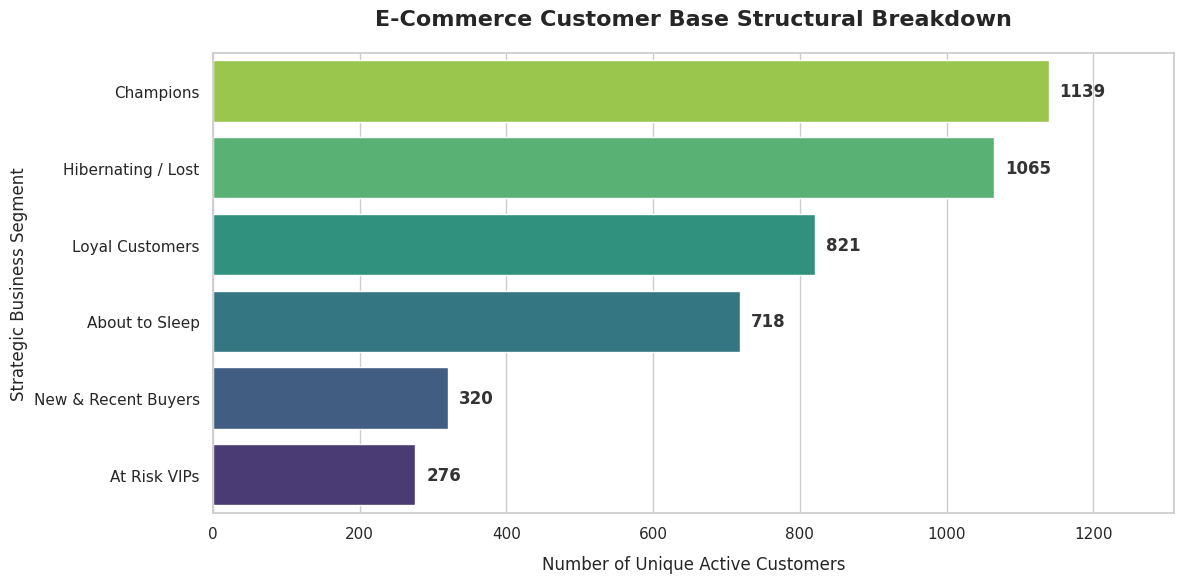

In [89]:

segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Customer Count']

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# horizontal bar chart showing the sizes of each human bucket
sns.barplot(
    data=segment_counts,
    x='Customer Count',
    y='Segment',
    palette='viridis_r',
    hue='Segment',
    legend=False
)


for index, row in segment_counts.iterrows():
    plt.text(
        row['Customer Count'] + 15, # Position text slightly to the right of the bar end
        index,                      # The horizontal line row index
        f"{int(row['Customer Count'])}",
        va='center',
        fontweight='bold',
        color='#333333'
    )

plt.title('E-Commerce Customer Base Structural Breakdown', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Unique Active Customers', fontsize=12, labelpad=10)
plt.ylabel('Strategic Business Segment', fontsize=12)

plt.xlim(0, max(segment_counts['Customer Count']) * 1.15)

plt.tight_layout()
plt.show()

| Segment             | Meaning                               | Business Action                         |
| ------------------- | ------------------------------------- | --------------------------------------- |
| Champions           | Highest-value customers               | Loyalty rewards and VIP treatment       |
| Loyal Customers     | Frequent repeat buyers                | Upselling and product recommendations   |
| New & Recent Buyers | Recently acquired customers           | Onboarding and engagement campaigns     |
| About to Sleep      | Customers becoming inactive           | Reminder emails and targeted promotions |
| At Risk VIPs        | High-value customers at risk of churn | Personalized retention campaigns        |
| Hibernating / Lost  | Inactive customers unlikely to return | Win-back offers and discounts           |


### Business Insight

The customer base consists primarily of Champions, Loyal Customers, and Hibernating/Lost Customers.

While the business has a strong core of highly engaged customers, a substantial number of customers have become inactive or are showing signs of disengagement.

The presence of 276 At-Risk VIPs is particularly important because these customers have historically generated significant value but may be close to churning.

### Why It Matters

Retaining existing customers is generally more cost-effective than acquiring new ones. Losing At-Risk VIPs could lead to a disproportionate decline in revenue.

### Recommended Action

- Reward Champions with exclusive loyalty benefits and early-access promotions.
- Upsell Loyal Customers through personalized recommendations.
- Launch targeted retention campaigns for At-Risk VIPs.
- Implement win-back campaigns for Hibernating/Lost Customers using special discounts and re-engagement emails.

### 6. Cohort Analysis

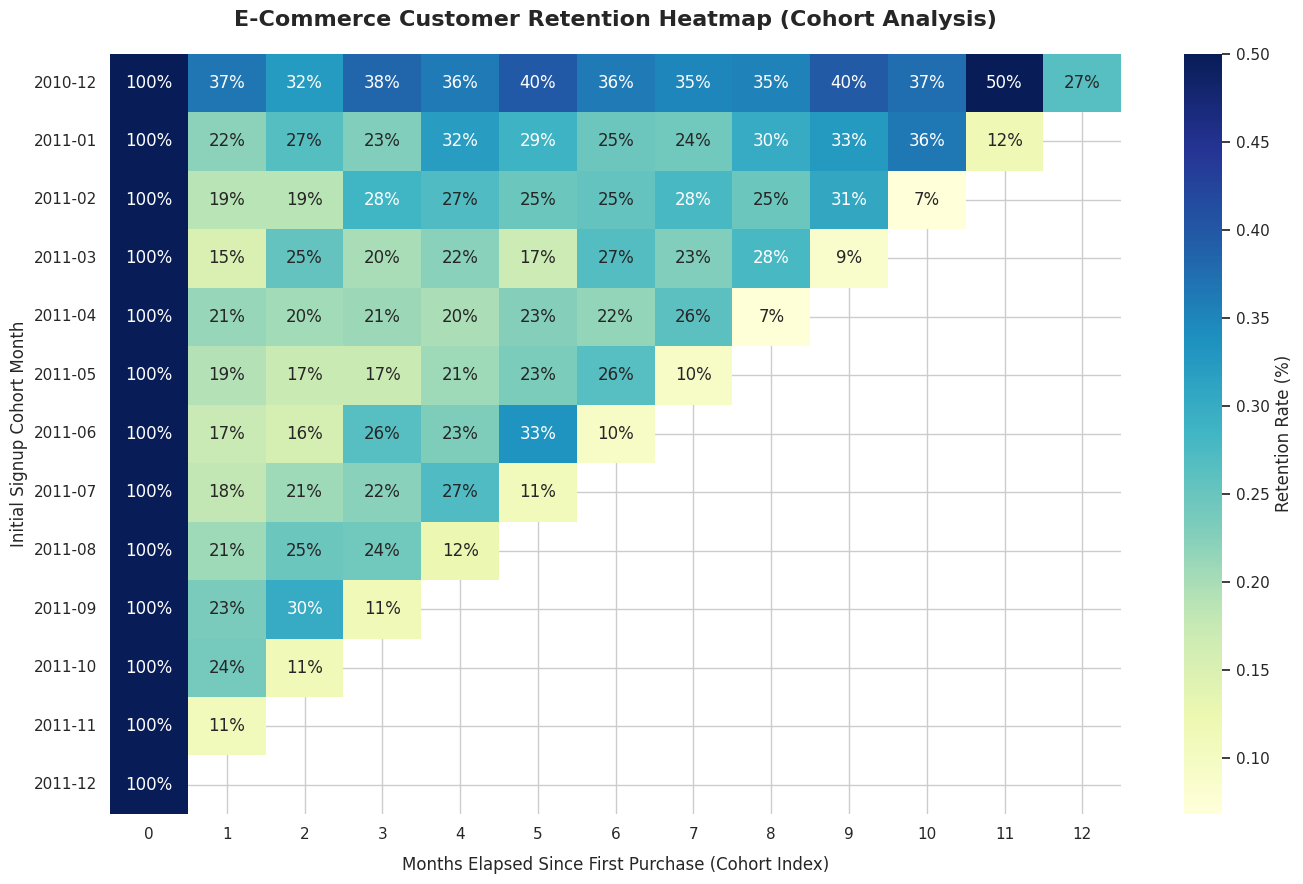

In [90]:
# Isolate each customer's absolute first purchase month (Cohort Month)
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceMonth'].transform('min')

# Calculate the "Cohort Index" (The number of months elapsed since their first order)
years_diff = df['InvoiceMonth'].dt.year - df['CohortMonth'].dt.year
months_diff = df['InvoiceMonth'].dt.month - df['CohortMonth'].dt.month
df['CohortIndex'] = years_diff * 12 + months_diff

cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()

# 4. Pivot the flat table into a broad grid matrix layout
cohort_matrix = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

# 5. Convert absolute customer counts into percentages relative to the starting Cohort size (Month 0)
cohort_sizes = cohort_matrix.iloc[:, 0]
retention_matrix = cohort_matrix.divide(cohort_sizes, axis=0)

# 6. Initialize a large 14x9 canvas grid for our visual matrix map
plt.figure(figsize=(14, 9))


sns.heatmap(
    data=retention_matrix,
    annot=True,
    fmt='.0%',
    cmap='YlGnBu',
    vmax=0.5,
    cbar_kws={'label': 'Retention Rate (%)'}
)


plt.title('E-Commerce Customer Retention Heatmap (Cohort Analysis)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Months Elapsed Since First Purchase (Cohort Index)', fontsize=12, labelpad=10)
plt.ylabel('Initial Signup Cohort Month', fontsize=12)

# 9. Clear up layout margins and present
plt.tight_layout()
plt.show()


### Business Insight

Customer retention is strongest immediately after acquisition but declines steadily over time across most cohorts.

The majority of customer attrition occurs within the first few months following the initial purchase.

### Why It Matters

Acquiring new customers is expensive. Improving retention rates can significantly increase customer lifetime value and reduce acquisition costs.

### Recommended Action

- Implement post-purchase engagement programs.
- Send personalized product recommendations.
- Introduce loyalty rewards and repeat-purchase incentives.
- Develop automated email campaigns during the first 90 days after acquisition.

# Key Findings

1. Revenue peaks during holiday seasons.
2. Sales are concentrated in a small number of products.
3. UK dominates total revenue contribution.
4. Champions contribute disproportionately to revenue.
5. Customer retention decreases significantly after Month 1.
6. Significant opportunity exists for reactivation campaigns.

# Strategic Business Recommendations

1. Focus marketing efforts on the September–November peak sales period.

2. Protect revenue-driving products through inventory optimization and product bundling strategies.

3. Expand operations in high-performing international markets such as the Netherlands, Germany, France, and EIRE.

4. Prioritize retention of Champions and At-Risk VIPs through loyalty and personalized engagement programs.

5. Improve customer retention during the first few months after acquisition through onboarding and repeat-purchase campaigns.

6. Increase customer lifetime value through cross-selling, upselling, and targeted segmentation-based marketing.

In [ ]:
# Export Clean Data
df.to_csv('cleaned_ecommerce_transactions.csv', index=False)

rfm.to_csv('customer_rfm_segments.csv', index=True)

print("CSVs successfully generated!")

#Power Bi Dashboard Link :